STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5

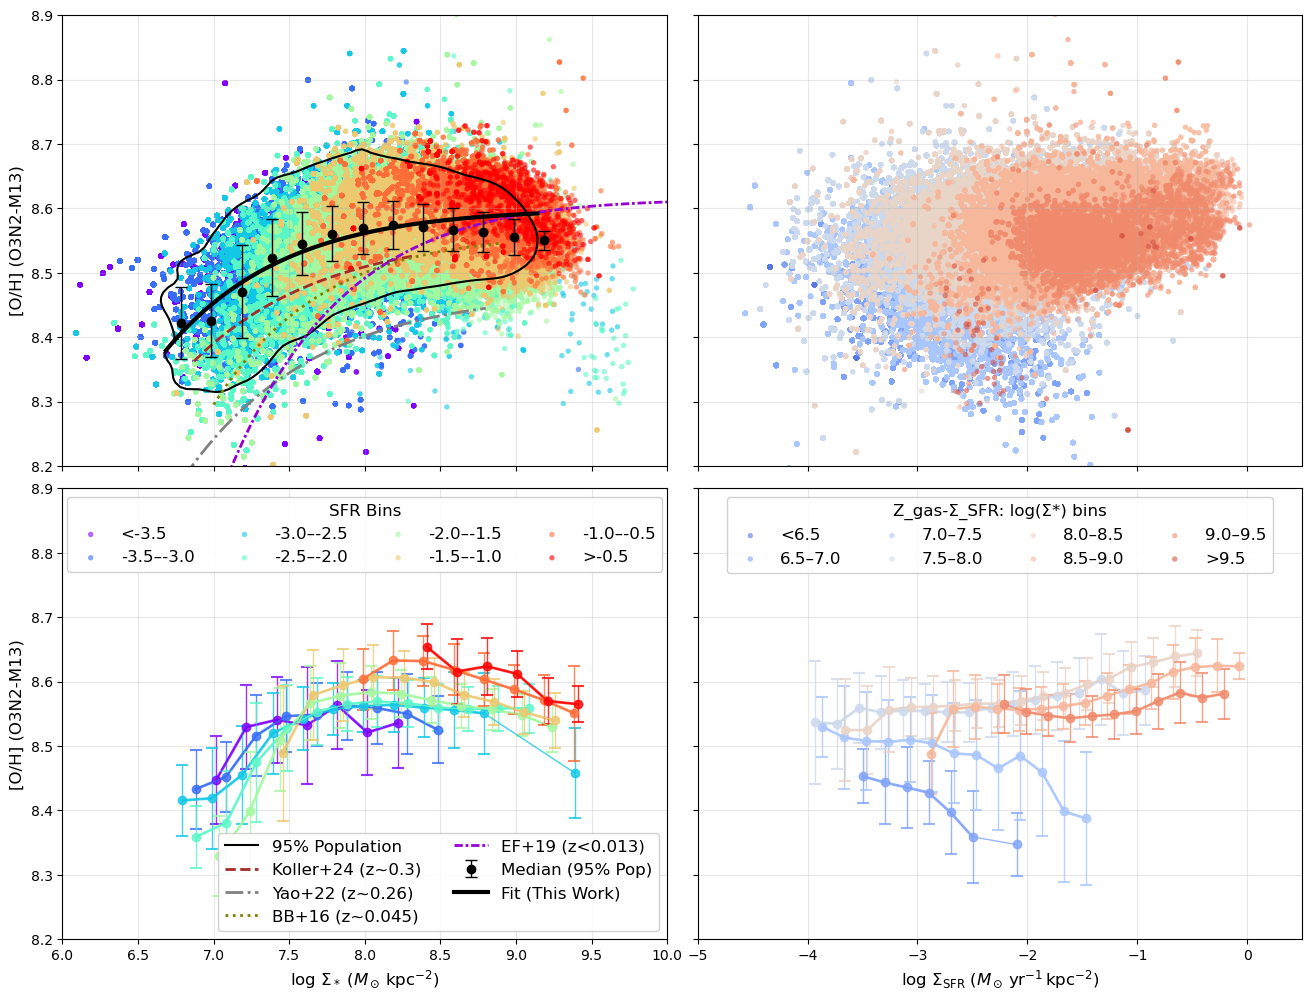


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Define the function form for fitting
def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def plot_literature_mzr_fits(ax, show_legend=True):
    """Plot literature rMZR / Σ*-Z fits on the given axis."""

    plot_data = []

    # --------------------------------------------------------------
    # 1) Yao+22 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_yao = np.linspace(6.8, 8.8, 200)
    a1, b1, c1 = 8.47, 0.0002, 12.36
    y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))
    plot_data.append((x_yao, y_yao22, 'Yao+22', '-.', 'gray'))

    # --------------------------------------------------------------
    # 2) Koller+24 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_koller = np.linspace(6.87, 8.33, 200)
    a2, b2, c2 = 8.561, 0.0001, 12.7
    y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))
    plot_data.append((x_koller, y_koller24, 'Koller+24', '--', 'brown'))

    # --------------------------------------------------------------
    # 3) Barrera-Ballesteros+16: local Σ*-Z (MaNGA, z~0.03)
    #    Σ_* is in Msun / kpc^2 in your plot → convert to Msun / pc^2
    #    log Σ_*[pc^-2] = log Σ_*[kpc^-2] - 6
    #    12+log(O/H) = Z0 - log10(1 + (Σ0 / Σ_*)^gamma)
    # --------------------------------------------------------------
    # Choose x-range overlapping your data; here 7–9 dex in Msun/kpc^2
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', ':', 'olive'))

    # --------------------------------------------------------------
    # 4) Erroz-Ferrer+19 (MAD, z < 0.013)
    # --------------------------------------------------------------
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, 'Erroz-Ferrer+19', (0, (3, 1, 1, 1)), 'darkviolet'))

    # --------------------------------------------------------------
    # Plot everything
    # --------------------------------------------------------------
    for x, y, label, linestyle, color in plot_data:
        if show_legend:
            ax.plot(x, y, label=label, linewidth=2,
                    linestyle=linestyle, color=color)
        else:
            ax.plot(x, y, linewidth=2,
                    linestyle=linestyle, color=color)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# --- Add Contour, Fits, and Median (95%) to Top-Left ---
# 2. 95% Contour
x_data = all_logSigmaM_HII
y_data = oh_data_HII
mask = np.isfinite(x_data) & np.isfinite(y_data)
x_clean = x_data[mask]
y_clean = y_data[mask]

xmin, xmax = 6, 10
ymin, ymax = 8.2, 8.9
nbins = 100
H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
sigma = 2.0
H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
H_flat = np.sort(H_smooth.ravel())[::-1]
H_sum = np.sum(H_flat)
H_cumsum = np.cumsum(H_flat)
idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
level_95 = H_flat[idx_95]
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# 3. Literature Fits
plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')
line_bb16 = plt.Line2D([0], [0], color='olive', linewidth=2, linestyle=':', label='BB+16')
line_ef19 = plt.Line2D([0], [0], color='darkviolet', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='EF+19 (z<0.013)')

# 4. Median Trend (within 95% contour)
dx = (xmax - xmin) / nbins
dy = (ymax - ymin) / nbins
x_idx = (x_clean - xmin) / dx - 0.5
y_idx = (y_clean - ymin) / dy - 0.5
point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
mask_95 = point_densities >= level_95
x_95 = x_clean[mask_95]
y_95 = y_clean[mask_95]
mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
    x_95, y_95, bin_width=0.2, min_pixels=20
)
median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
            fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# 5. Fit current data
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
try:
    popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
    # Limit fit to min/max of 95% contour
    x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit = mzr_model(x_fit, *popt)
    fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
    print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
except Exception as e:
    print(f"Fitting failed: {e}")
    fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add SFR bin legend to bottom panel (Top Center)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9, title='SFR Bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)

# Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
handles_bl = [contour_line, line_koller, line_yao, line_bb16, line_ef19, median_95_err, fit_line]
labels_bl = ['95% Population', 'Koller+24 (z~0.3)', 'Yao+22 (z~0.26)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Median (95% Pop)', 'Fit (This Work)']
ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
                     ncol=2, fontsize=12, framealpha=0.9)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9,
                     title='Z_gas-Σ_SFR: log(Σ*) bins', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 

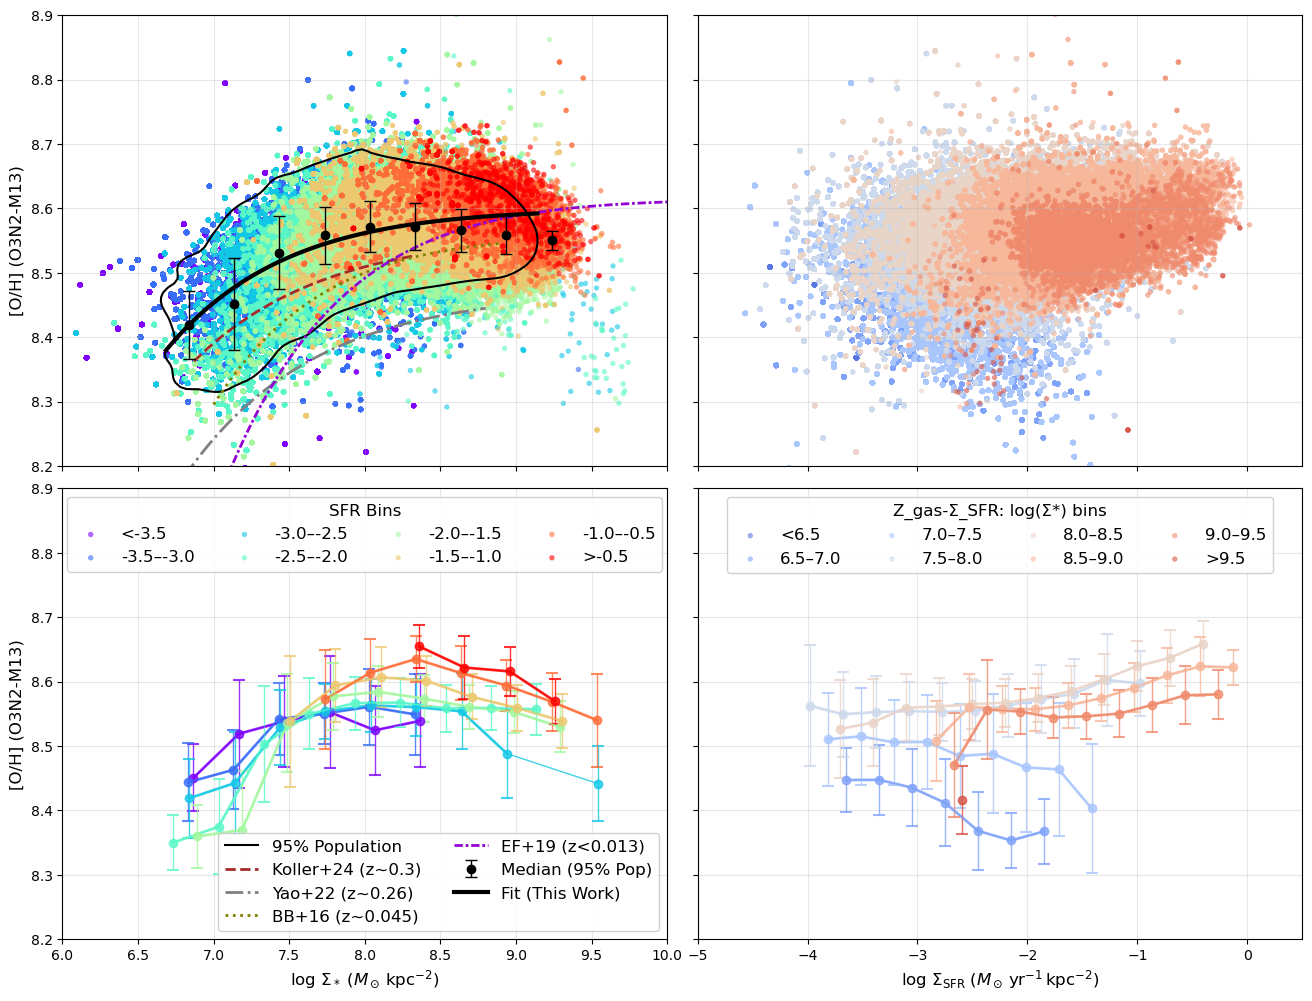


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [2]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.3, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Define the function form for fitting
def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def plot_literature_mzr_fits(ax, show_legend=True):
    """Plot literature rMZR / Σ*-Z fits on the given axis."""

    plot_data = []

    # --------------------------------------------------------------
    # 1) Yao+22 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_yao = np.linspace(6.8, 8.8, 200)
    a1, b1, c1 = 8.47, 0.0002, 12.36
    y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))
    plot_data.append((x_yao, y_yao22, 'Yao+22', '-.', 'gray'))

    # --------------------------------------------------------------
    # 2) Koller+24 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_koller = np.linspace(6.87, 8.33, 200)
    a2, b2, c2 = 8.561, 0.0001, 12.7
    y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))
    plot_data.append((x_koller, y_koller24, 'Koller+24', '--', 'brown'))

    # --------------------------------------------------------------
    # 3) Barrera-Ballesteros+16: local Σ*-Z (MaNGA, z~0.03)
    #    Σ_* is in Msun / kpc^2 in your plot → convert to Msun / pc^2
    #    log Σ_*[pc^-2] = log Σ_*[kpc^-2] - 6
    #    12+log(O/H) = Z0 - log10(1 + (Σ0 / Σ_*)^gamma)
    # --------------------------------------------------------------
    # Choose x-range overlapping your data; here 7–9 dex in Msun/kpc^2
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', ':', 'olive'))

    # --------------------------------------------------------------
    # 4) Erroz-Ferrer+19 (MAD, z < 0.013)
    # --------------------------------------------------------------
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, 'Erroz-Ferrer+19', (0, (3, 1, 1, 1)), 'darkviolet'))

    # --------------------------------------------------------------
    # Plot everything
    # --------------------------------------------------------------
    for x, y, label, linestyle, color in plot_data:
        if show_legend:
            ax.plot(x, y, label=label, linewidth=2,
                    linestyle=linestyle, color=color)
        else:
            ax.plot(x, y, linewidth=2,
                    linestyle=linestyle, color=color)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.3, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# --- Add Contour, Fits, and Median (95%) to Top-Left ---
# 2. 95% Contour
x_data = all_logSigmaM_HII
y_data = oh_data_HII
mask = np.isfinite(x_data) & np.isfinite(y_data)
x_clean = x_data[mask]
y_clean = y_data[mask]

xmin, xmax = 6, 10
ymin, ymax = 8.2, 8.9
nbins = 100
H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
sigma = 2.0
H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
H_flat = np.sort(H_smooth.ravel())[::-1]
H_sum = np.sum(H_flat)
H_cumsum = np.cumsum(H_flat)
idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
level_95 = H_flat[idx_95]
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# 3. Literature Fits
plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')
line_bb16 = plt.Line2D([0], [0], color='olive', linewidth=2, linestyle=':', label='BB+16')
line_ef19 = plt.Line2D([0], [0], color='darkviolet', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='EF+19 (z<0.013)')

# 4. Median Trend (within 95% contour)
dx = (xmax - xmin) / nbins
dy = (ymax - ymin) / nbins
x_idx = (x_clean - xmin) / dx - 0.5
y_idx = (y_clean - ymin) / dy - 0.5
point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
mask_95 = point_densities >= level_95
x_95 = x_clean[mask_95]
y_95 = y_clean[mask_95]
mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
    x_95, y_95, bin_width=0.3, min_pixels=20
)
median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
            fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# 5. Fit current data
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
try:
    popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
    # Limit fit to min/max of 95% contour
    x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit = mzr_model(x_fit, *popt)
    fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
    print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
except Exception as e:
    print(f"Fitting failed: {e}")
    fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add SFR bin legend to bottom panel (Top Center)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9, title='SFR Bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)

# Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
handles_bl = [contour_line, line_koller, line_yao, line_bb16, line_ef19, median_95_err, fit_line]
labels_bl = ['95% Population', 'Koller+24 (z~0.3)', 'Yao+22 (z~0.26)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Median (95% Pop)', 'Fit (This Work)']
ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
                     ncol=2, fontsize=12, framealpha=0.9)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.3, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9,
                     title='Z_gas-Σ_SFR: log(Σ*) bins', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  B

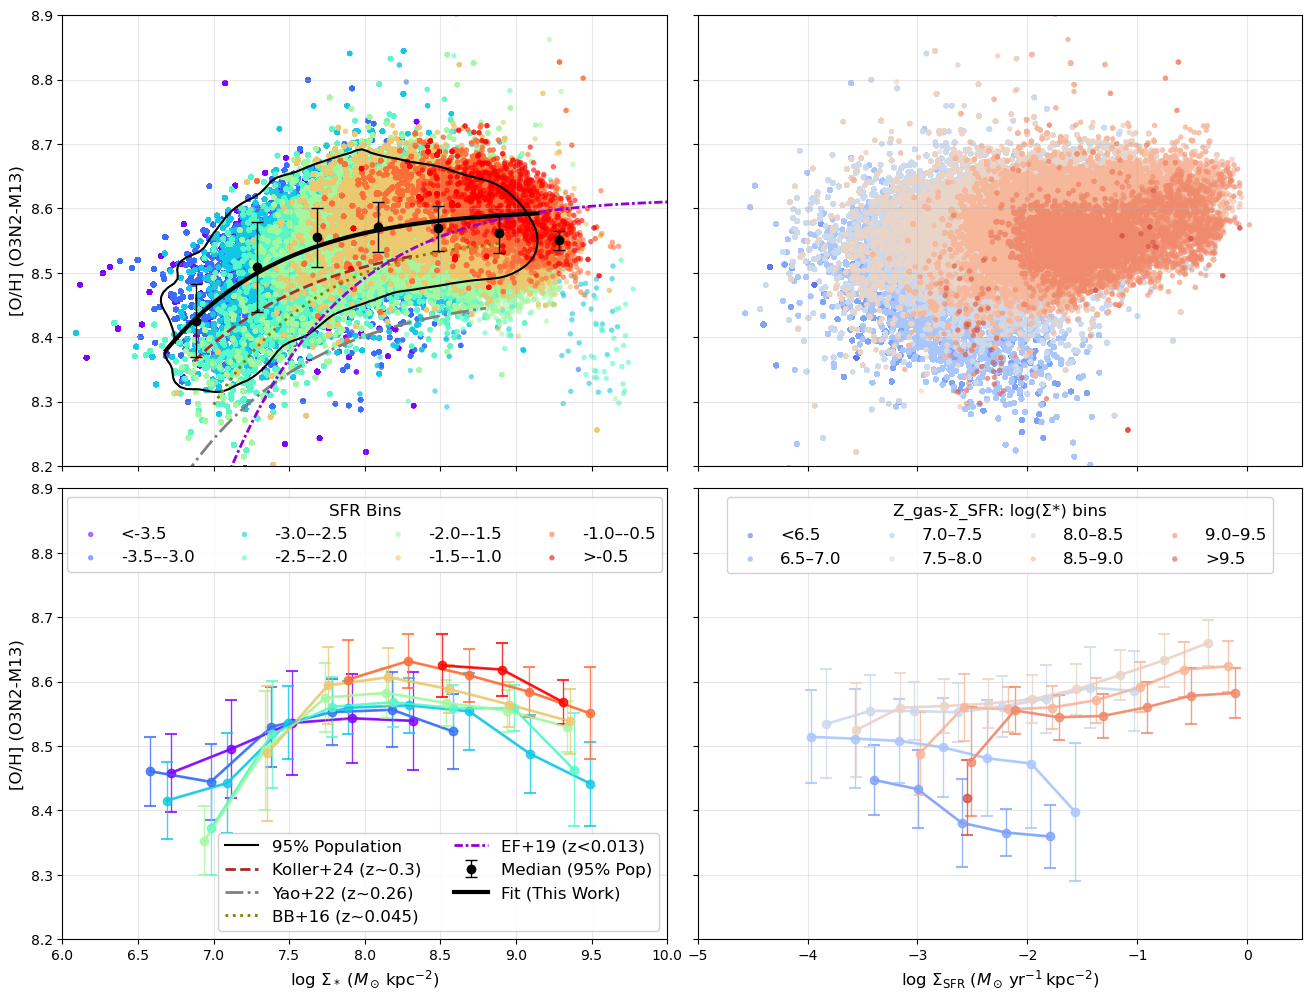


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [3]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Define the function form for fitting
def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def plot_literature_mzr_fits(ax, show_legend=True):
    """Plot literature rMZR / Σ*-Z fits on the given axis."""

    plot_data = []

    # --------------------------------------------------------------
    # 1) Yao+22 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_yao = np.linspace(6.8, 8.8, 200)
    a1, b1, c1 = 8.47, 0.0002, 12.36
    y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))
    plot_data.append((x_yao, y_yao22, 'Yao+22', '-.', 'gray'))

    # --------------------------------------------------------------
    # 2) Koller+24 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_koller = np.linspace(6.87, 8.33, 200)
    a2, b2, c2 = 8.561, 0.0001, 12.7
    y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))
    plot_data.append((x_koller, y_koller24, 'Koller+24', '--', 'brown'))

    # --------------------------------------------------------------
    # 3) Barrera-Ballesteros+16: local Σ*-Z (MaNGA, z~0.03)
    #    Σ_* is in Msun / kpc^2 in your plot → convert to Msun / pc^2
    #    log Σ_*[pc^-2] = log Σ_*[kpc^-2] - 6
    #    12+log(O/H) = Z0 - log10(1 + (Σ0 / Σ_*)^gamma)
    # --------------------------------------------------------------
    # Choose x-range overlapping your data; here 7–9 dex in Msun/kpc^2
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', ':', 'olive'))

    # --------------------------------------------------------------
    # 4) Erroz-Ferrer+19 (MAD, z < 0.013)
    # --------------------------------------------------------------
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, 'Erroz-Ferrer+19', (0, (3, 1, 1, 1)), 'darkviolet'))

    # --------------------------------------------------------------
    # Plot everything
    # --------------------------------------------------------------
    for x, y, label, linestyle, color in plot_data:
        if show_legend:
            ax.plot(x, y, label=label, linewidth=2,
                    linestyle=linestyle, color=color)
        else:
            ax.plot(x, y, linewidth=2,
                    linestyle=linestyle, color=color)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.4, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# --- Add Contour, Fits, and Median (95%) to Top-Left ---
# 2. 95% Contour
x_data = all_logSigmaM_HII
y_data = oh_data_HII
mask = np.isfinite(x_data) & np.isfinite(y_data)
x_clean = x_data[mask]
y_clean = y_data[mask]

xmin, xmax = 6, 10
ymin, ymax = 8.2, 8.9
nbins = 100
H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
sigma = 2.0
H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
H_flat = np.sort(H_smooth.ravel())[::-1]
H_sum = np.sum(H_flat)
H_cumsum = np.cumsum(H_flat)
idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
level_95 = H_flat[idx_95]
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# 3. Literature Fits
plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')
line_bb16 = plt.Line2D([0], [0], color='olive', linewidth=2, linestyle=':', label='BB+16')
line_ef19 = plt.Line2D([0], [0], color='darkviolet', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='EF+19 (z<0.013)')

# 4. Median Trend (within 95% contour)
dx = (xmax - xmin) / nbins
dy = (ymax - ymin) / nbins
x_idx = (x_clean - xmin) / dx - 0.5
y_idx = (y_clean - ymin) / dy - 0.5
point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
mask_95 = point_densities >= level_95
x_95 = x_clean[mask_95]
y_95 = y_clean[mask_95]
mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
    x_95, y_95, bin_width=0.4, min_pixels=20
)
median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
            fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# 5. Fit current data
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
try:
    popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
    # Limit fit to min/max of 95% contour
    x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit = mzr_model(x_fit, *popt)
    fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
    print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
except Exception as e:
    print(f"Fitting failed: {e}")
    fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add SFR bin legend to bottom panel (Top Center)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9, title='SFR Bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)

# Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
handles_bl = [contour_line, line_koller, line_yao, line_bb16, line_ef19, median_95_err, fit_line]
labels_bl = ['95% Population', 'Koller+24 (z~0.3)', 'Yao+22 (z~0.26)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Median (95% Pop)', 'Fit (This Work)']
ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
                     ncol=2, fontsize=12, framealpha=0.9)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.4, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9,
                     title='Z_gas-Σ_SFR: log(Σ*) bins', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–

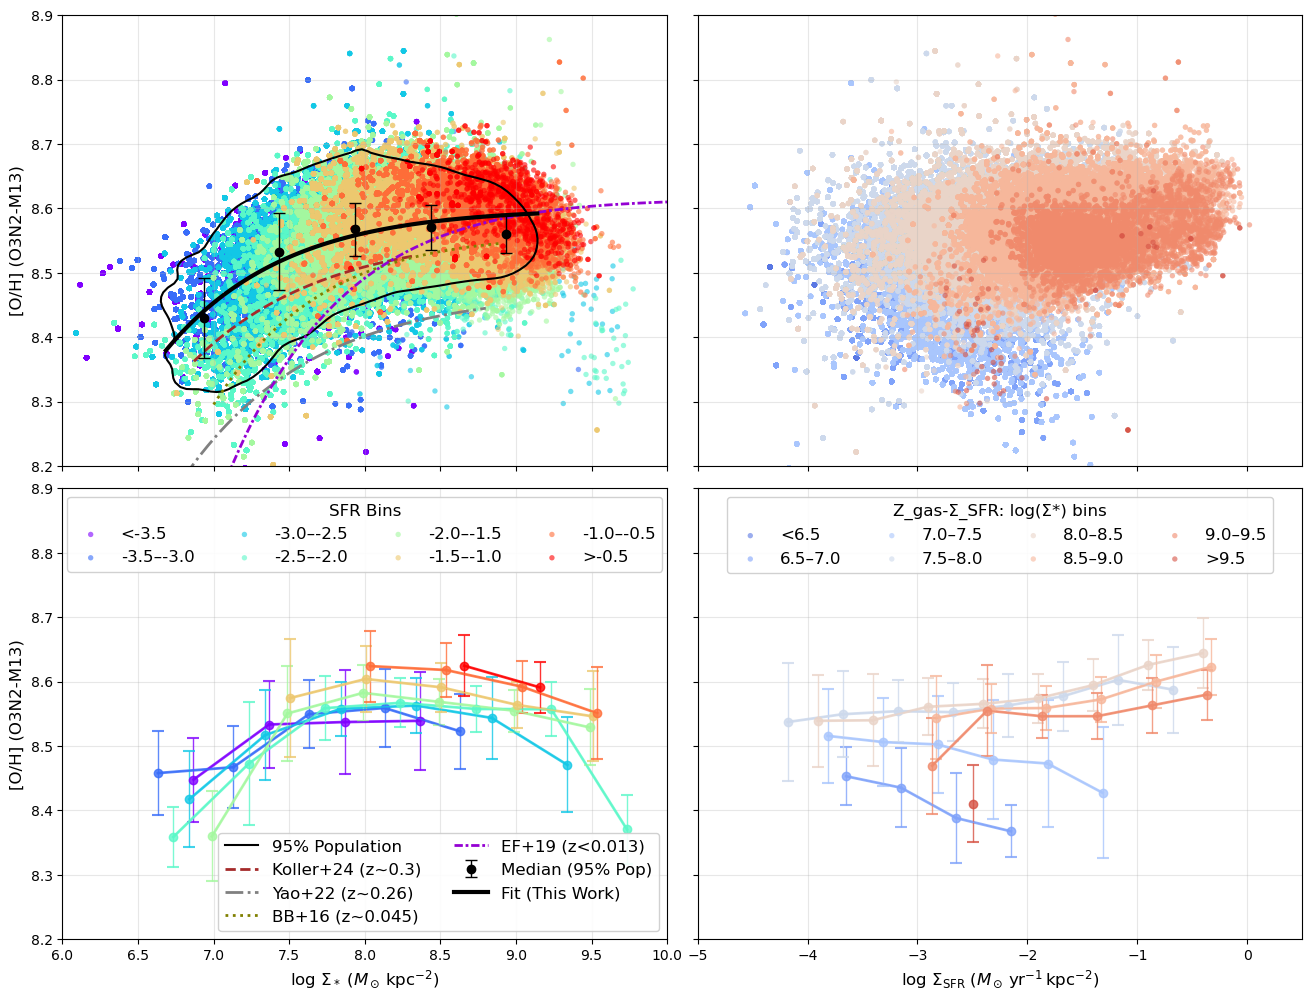


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [4]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.5, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Define the function form for fitting
def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def plot_literature_mzr_fits(ax, show_legend=True):
    """Plot literature rMZR / Σ*-Z fits on the given axis."""

    plot_data = []

    # --------------------------------------------------------------
    # 1) Yao+22 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_yao = np.linspace(6.8, 8.8, 200)
    a1, b1, c1 = 8.47, 0.0002, 12.36
    y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))
    plot_data.append((x_yao, y_yao22, 'Yao+22', '-.', 'gray'))

    # --------------------------------------------------------------
    # 2) Koller+24 (global MZR; your current parametrisation)
    # --------------------------------------------------------------
    x_koller = np.linspace(6.87, 8.33, 200)
    a2, b2, c2 = 8.561, 0.0001, 12.7
    y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))
    plot_data.append((x_koller, y_koller24, 'Koller+24', '--', 'brown'))

    # --------------------------------------------------------------
    # 3) Barrera-Ballesteros+16: local Σ*-Z (MaNGA, z~0.03)
    #    Σ_* is in Msun / kpc^2 in your plot → convert to Msun / pc^2
    #    log Σ_*[pc^-2] = log Σ_*[kpc^-2] - 6
    #    12+log(O/H) = Z0 - log10(1 + (Σ0 / Σ_*)^gamma)
    # --------------------------------------------------------------
    # Choose x-range overlapping your data; here 7–9 dex in Msun/kpc^2
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', ':', 'olive'))

    # --------------------------------------------------------------
    # 4) Erroz-Ferrer+19 (MAD, z < 0.013)
    # --------------------------------------------------------------
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, 'Erroz-Ferrer+19', (0, (3, 1, 1, 1)), 'darkviolet'))

    # --------------------------------------------------------------
    # Plot everything
    # --------------------------------------------------------------
    for x, y, label, linestyle, color in plot_data:
        if show_legend:
            ax.plot(x, y, label=label, linewidth=2,
                    linestyle=linestyle, color=color)
        else:
            ax.plot(x, y, linewidth=2,
                    linestyle=linestyle, color=color)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.5, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# --- Add Contour, Fits, and Median (95%) to Top-Left ---
# 2. 95% Contour
x_data = all_logSigmaM_HII
y_data = oh_data_HII
mask = np.isfinite(x_data) & np.isfinite(y_data)
x_clean = x_data[mask]
y_clean = y_data[mask]

xmin, xmax = 6, 10
ymin, ymax = 8.2, 8.9
nbins = 100
H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
sigma = 2.0
H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
H_flat = np.sort(H_smooth.ravel())[::-1]
H_sum = np.sum(H_flat)
H_cumsum = np.cumsum(H_flat)
idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
level_95 = H_flat[idx_95]
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# 3. Literature Fits
plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')
line_bb16 = plt.Line2D([0], [0], color='olive', linewidth=2, linestyle=':', label='BB+16')
line_ef19 = plt.Line2D([0], [0], color='darkviolet', linewidth=2, linestyle=(0, (3, 1, 1, 1)), label='EF+19 (z<0.013)')

# 4. Median Trend (within 95% contour)
dx = (xmax - xmin) / nbins
dy = (ymax - ymin) / nbins
x_idx = (x_clean - xmin) / dx - 0.5
y_idx = (y_clean - ymin) / dy - 0.5
point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
mask_95 = point_densities >= level_95
x_95 = x_clean[mask_95]
y_95 = y_clean[mask_95]
mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
    x_95, y_95, bin_width=0.5, min_pixels=20
)
median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
            fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# 5. Fit current data
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
try:
    popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
    # Limit fit to min/max of 95% contour
    x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
    y_fit = mzr_model(x_fit, *popt)
    fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
    print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
except Exception as e:
    print(f"Fitting failed: {e}")
    fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add SFR bin legend to bottom panel (Top Center)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9, title='SFR Bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)

# Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
handles_bl = [contour_line, line_koller, line_yao, line_bb16, line_ef19, median_95_err, fit_line]
labels_bl = ['95% Population', 'Koller+24 (z~0.3)', 'Yao+22 (z~0.26)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Median (95% Pop)', 'Fit (This Work)']
ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
                     ncol=2, fontsize=12, framealpha=0.9)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.5, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9,
                     title='Z_gas-Σ_SFR: log(Σ*) bins', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
